In [1]:
import numpy as np
from typing import List, Tuple, Dict, Optional, Set
import re
from dataclasses import dataclass, field
import urllib.request
import tempfile
import os
from pathlib import Path
import copy

# Visualization imports
try:
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    from matplotlib.lines import Line2D
    import matplotlib.gridspec as gridspec
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False
    print("Warning: matplotlib not available. Install with: pip install matplotlib")
try:
    import plotly.graph_objects as go
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Warning: plotly not available. Install with: pip install plotly")


@dataclass
class Bead:
    """Represents a coarse-grained bead in the three-bead model."""
    bead_type: str
    chain_id: str
    position: np.ndarray
    residue_id: int
    atom_name: str
    base_type: Optional[str] = None


@dataclass
class BeadBond:
    """Represents a bond between two beads."""
    bead1_idx: int
    bead2_idx: int
    bond_type: str
    equilibrium_length: float


@dataclass
class BasePair:
    """Represents a base pair interaction."""
    base1_idx: int
    base2_idx: int
    pair_type: str
    res1_id: int
    res2_id: int


@dataclass
class BasePairRestraint:
    """Harmonic restraint derived from a predicted base pair.

    U_rest = k_rest * (r_ij - r0_NN)^2

    where r_ij is the current N–N distance for this pair and r0_NN is
    the target equilibrium N–N distance (from the TiRNA force field).
    """
    base1_idx: int
    base2_idx: int
    pair_type: str
    r0: float          # equilibrium N–N distance (Å)
    k_rest: float      # harmonic spring constant (kcal/mol/Å²)
    res1_id: int
    res2_id: int


class PDBDownloader:
    """Download PDB files from the RCSB PDB database."""

    RCSB_URL = "https://files.rcsb.org/download"

    @staticmethod
    def download_pdb(pdb_id: str, save_path: str = None) -> str:
        pdb_id = pdb_id.upper().strip()
        if len(pdb_id) != 4:
            raise ValueError(f"Invalid PDB ID: {pdb_id}. PDB IDs must be 4 characters.")
        url = f"{PDBDownloader.RCSB_URL}/{pdb_id}.pdb"
        if save_path is None:
            temp_dir = tempfile.gettempdir()
            save_path = os.path.join(temp_dir, f"{pdb_id}.pdb")
        else:
            os.makedirs(os.path.dirname(save_path) if os.path.dirname(save_path) else '.',
                        exist_ok=True)
        try:
            print(f"Downloading PDB structure {pdb_id}...")
            urllib.request.urlretrieve(url, save_path)
            print(f"✓ Successfully downloaded to: {save_path}")
            return save_path
        except Exception as e:
            raise RuntimeError(f"Failed to download PDB {pdb_id}: {str(e)}")

    @staticmethod
    def pdb_exists(pdb_id: str) -> bool:
        pdb_id = pdb_id.upper().strip()
        url = f"{PDBDownloader.RCSB_URL}/{pdb_id}.pdb"
        try:
            request = urllib.request.Request(url, method='HEAD')
            urllib.request.urlopen(request, timeout=5)
            return True
        except:
            return False


class PDBParser:
    """Parse RNA PDB format files and extract atomic coordinates."""

    @staticmethod
    def parse_pdb(pdb_file: str) -> Dict:
        atoms = []
        if not os.path.exists(pdb_file):
            raise FileNotFoundError(f"PDB file not found: {pdb_file}")
        with open(pdb_file, 'r') as f:
            for line in f:
                if line.startswith('ATOM') or line.startswith('HETATM'):
                    try:
                        atom_data = {
                            'atom_number': int(line[6:11].strip()),
                            'atom_name': line[12:16].strip(),
                            'residue_name': line[17:20].strip(),
                            'chain_id': line[21].strip(),
                            'residue_id': int(line[22:26].strip()),
                            'x': float(line[30:38].strip()),
                            'y': float(line[38:46].strip()),
                            'z': float(line[46:54].strip()),
                            'occupancy': float(line[54:60].strip()) if len(line) > 60 else 1.0,
                            'b_factor': float(line[60:66].strip()) if len(line) > 66 else 0.0,
                        }
                        atoms.append(atom_data)
                    except (ValueError, IndexError):
                        continue
        if not atoms:
            raise ValueError(f"No ATOM records found in {pdb_file}")
        return {'atoms': atoms}


class BasePairingPredictor:
    """Predict base pairs from RNA structure."""

    BASE_TYPE_MAP = {
        'A': 'A', 'ADE': 'A', 'DA': 'A',
        'U': 'U', 'URI': 'U', 'DU': 'U',
        'G': 'G', 'GUA': 'G', 'DG': 'G',
        'C': 'C', 'CYT': 'C', 'DC': 'C',
    }

    ALLOWED_PAIRS = {
        ('A', 'U'): 'AU', ('U', 'A'): 'AU',
        ('G', 'C'): 'GC', ('C', 'G'): 'GC',
        ('G', 'U'): 'GU', ('U', 'G'): 'GU',
    }

    DISTANCE_THRESHOLDS = {'GC': 8.5, 'AU': 8.5, 'GU': 8.5}

    @staticmethod
    def get_base_type(residue_name: str) -> Optional[str]:
        residue_name = residue_name.upper().strip()
        return BasePairingPredictor.BASE_TYPE_MAP.get(residue_name)

    @staticmethod
    def predict_base_pairs(model: 'ThreeBeadModel', atoms: List[Dict],
                           min_separation: int = 3) -> List[BasePair]:
        # Build (chain_id, residue_id) → base_type map from raw atoms
        residue_to_base = {}
        for atom in atoms:
            chain_id = atom.get('chain_id', '')
            res_id = atom['residue_id']
            key = (chain_id, res_id)
            if key not in residue_to_base:
                base_type = BasePairingPredictor.get_base_type(atom['residue_name'])
                if base_type:
                    residue_to_base[key] = base_type
    
        # Assign base_type to N beads (now using chain_id too)
        for i, bead in enumerate(model.beads):
            if bead.bead_type == 'N':
                key = (bead.chain_id, bead.residue_id)
                if key in residue_to_base:
                    bead.base_type = residue_to_base[key]
    
        base_beads = [i for i, bead in enumerate(model.beads) if bead.bead_type == 'N']
        predicted_pairs = []
    
        for i in range(len(base_beads)):
            for j in range(i + 1, len(base_beads)):           # ← start at i+1
                bead1_idx = base_beads[i]
                bead2_idx = base_beads[j]
                bead1 = model.beads[bead1_idx]
                bead2 = model.beads[bead2_idx]
    
                # ── Chain-aware min_separation ──
                same_chain = (bead1.chain_id == bead2.chain_id)
                if same_chain and (j - i) < min_separation:
                    # Intra-chain: enforce loop constraint
                    continue
                # Inter-chain: no sequence distance constraint needed
    
                if not (bead1.base_type and bead2.base_type):
                    continue
                base_pair_key = (bead1.base_type, bead2.base_type)
                if base_pair_key not in BasePairingPredictor.ALLOWED_PAIRS:
                    continue
                distance = np.linalg.norm(bead1.position - bead2.position)
                pair_type = BasePairingPredictor.ALLOWED_PAIRS[base_pair_key]
                threshold = BasePairingPredictor.DISTANCE_THRESHOLDS.get(pair_type, 9.0)
                if distance < threshold:
                    predicted_pairs.append(BasePair(
                        base1_idx=bead1_idx, base2_idx=bead2_idx,
                        pair_type=pair_type,
                        res1_id=bead1.residue_id, res2_id=bead2.residue_id
                    ))
        return predicted_pairs

    @staticmethod
    def filter_conflicting_pairs(base_pairs: List[BasePair],
                                 model: 'ThreeBeadModel') -> List[BasePair]:
        """Remove conflicting base pairs.
        
        Priority order:
          1. Pair type strength: GC (3) > AU (2) > GU (1)
          2. Tie-breaker: shorter N–N distance wins
        """
        used_bases = set()
        filtered_pairs = []
        pair_priority = {'GC': 3, 'AU': 2, 'GU': 1}

        def sort_key(bp: BasePair):
            priority = pair_priority.get(bp.pair_type, 0)
            distance = np.linalg.norm(
                model.beads[bp.base1_idx].position -
                model.beads[bp.base2_idx].position
            )
            return (-priority, distance)

        sorted_pairs = sorted(base_pairs, key=sort_key)

        for bp in sorted_pairs:
            if bp.base1_idx not in used_bases and bp.base2_idx not in used_bases:
                filtered_pairs.append(bp)
                used_bases.add(bp.base1_idx)
                used_bases.add(bp.base2_idx)
        return filtered_pairs


class ThreeBeadModel:
    """Coarse-grained three-bead model for RNA structure (TiRNA representation)."""

    def __init__(self):
        self.beads: List[Bead] = []
        self.bonds: List[BeadBond] = []
        self.angles: List[Tuple[int, int, int, str]] = []
        self.dihedrals: List[Tuple[int, int, int, int, str]] = []
        self.base_pairs: List[BasePair] = []
        self.bp_restraints: List[BasePairRestraint] = []   # <-- NEW
        self.initial_positions = None
        self.original_pdb_atoms = None
        self.atom_to_bead = {
            'P': 'P', "O5'": 'P', "O3'": 'P',
            "C5'": 'C', "C4'": 'C', "C3'": 'C', "O4'": 'C', "C1'": 'C', "C2'": 'C',
            'N1': 'N', 'N3': 'N', 'N7': 'N', 'N9': 'N',
            'C2': 'N', 'C4': 'N', 'C6': 'N', 'C8': 'N',
            'O2': 'N', 'O4': 'N', 'O6': 'N',
        }

    # ──── MODIFIED build_from_atoms ────
    def build_from_atoms(self, atoms: List[Dict]) -> None:
        self.original_pdb_atoms = atoms.copy()
        bead_positions = {}
        for atom in atoms:
            chain_id = atom.get('chain_id', '')          # ← NEW: read chain
            res_id = atom['residue_id']
            atom_name = atom['atom_name']
            bead_type = self.atom_to_bead.get(atom_name)
            if bead_type is None:
                continue
            key = (chain_id, res_id, bead_type)          # ← NEW: 3-tuple key
            if key not in bead_positions:
                bead_positions[key] = []
            bead_positions[key].append(np.array([atom['x'], atom['y'], atom['z']]))
    
        # residue_beads is now keyed by chain_id → {res_id → {bead_type → bead_idx}}
        residue_beads: Dict[str, Dict[int, Dict[str, int]]] = {}
        bead_counter = 0
        for (chain_id, res_id, bead_type), positions in sorted(bead_positions.items()):
            center_of_mass = np.mean(positions, axis=0)
            bead = Bead(
                bead_type=bead_type,
                position=center_of_mass,
                residue_id=res_id,
                atom_name=f"{bead_type}_{chain_id}_{res_id}",
                chain_id=chain_id,                       # ← NEW: store chain
            )
            self.beads.append(bead)
            if chain_id not in residue_beads:
                residue_beads[chain_id] = {}
            if res_id not in residue_beads[chain_id]:
                residue_beads[chain_id][res_id] = {}
            residue_beads[chain_id][res_id][bead_type] = bead_counter
            bead_counter += 1
    
        # Store the set of chain IDs for later use
        self.chain_ids = sorted(residue_beads.keys())
    
        self.initial_positions = [bead.position.copy() for bead in self.beads]
    
        # Bonded terms are built PER CHAIN (strictly intra-molecular)
        for chain_id in self.chain_ids:
            chain_res_beads = residue_beads[chain_id]
            self._create_bonds(chain_res_beads)
            self._create_angles(chain_res_beads)
            self._create_dihedrals(chain_res_beads)
    
        # Base pairs span ALL chains (handled inside predict_base_pairs)
        self.base_pairs = BasePairingPredictor.predict_base_pairs(self, atoms)
        self.base_pairs = BasePairingPredictor.filter_conflicting_pairs(self.base_pairs, self)

    def _create_bonds(self, residue_beads: Dict) -> None:
        residues = sorted(residue_beads.keys())
        for res_id in residues:
            beads_in_res = residue_beads[res_id]
            if 'P' in beads_in_res and 'C' in beads_in_res:
                self.bonds.append(BeadBond(beads_in_res['P'], beads_in_res['C'], 'P_i-C_i', 3.9))
            if 'C' in beads_in_res and 'N' in beads_in_res:
                self.bonds.append(BeadBond(beads_in_res['C'], beads_in_res['N'], 'C_i-N_i', 3.4))
        for i in range(len(residues) - 1):
            res1_id = residues[i]
            res2_id = residues[i + 1]
            if 'C' in residue_beads[res1_id] and 'P' in residue_beads[res2_id]:
                self.bonds.append(BeadBond(residue_beads[res1_id]['C'],
                                           residue_beads[res2_id]['P'], 'C_i-P_(i+1)', 3.9))

    def _create_angles(self, residue_beads: Dict) -> None:
        residues = sorted(residue_beads.keys())
        for res_id in residues:
            beads_in_res = residue_beads[res_id]
            if 'P' in beads_in_res and 'C' in beads_in_res:
                p_idx = beads_in_res['P']
                c_idx = beads_in_res['C']
                if res_id + 1 in residue_beads and 'P' in residue_beads[res_id + 1]:
                    self.angles.append((p_idx, c_idx, residue_beads[res_id + 1]['P'], 'P_i-C_i-P_(i+1)'))
            if 'P' in beads_in_res and 'C' in beads_in_res:
                p_idx = beads_in_res['P']
                c_idx = beads_in_res['C']
                if res_id - 1 in residue_beads and 'C' in residue_beads[res_id - 1]:
                    self.angles.append((residue_beads[res_id - 1]['C'], p_idx, c_idx, 'C_(i-1)-P_i-C_i'))
            if 'P' in beads_in_res and 'C' in beads_in_res and 'N' in beads_in_res:
                self.angles.append((beads_in_res['P'], beads_in_res['C'], beads_in_res['N'], 'P_i-C_i-N_i'))
            if 'C' in beads_in_res and 'N' in beads_in_res:
                c_idx = beads_in_res['C']
                n_idx = beads_in_res['N']
                if res_id + 1 in residue_beads and 'P' in residue_beads[res_id + 1]:
                    self.angles.append((n_idx, c_idx, residue_beads[res_id + 1]['P'], 'N_i-C_i-P_(i+1)'))

    def _create_dihedrals(self, residue_beads: Dict) -> None:
        residues = sorted(residue_beads.keys())
        for res_id in residues:
            beads_in_res = residue_beads[res_id]
            if 'P' in beads_in_res and 'C' in beads_in_res:
                if res_id + 1 in residue_beads and 'P' in residue_beads[res_id + 1] and 'C' in residue_beads[res_id + 1]:
                    self.dihedrals.append((
                        beads_in_res['P'], beads_in_res['C'],
                        residue_beads[res_id + 1]['P'], residue_beads[res_id + 1]['C'],
                        'P_i-C_i-P_(i+1)-C_(i+1)'))


class RMSDCalculator:
    """Calculate RMSD between structures."""

    @staticmethod
    def calculate_rmsd(coord1: np.ndarray, coord2: np.ndarray) -> float:
        if len(coord1) != len(coord2):
            raise ValueError("Coordinate arrays must have the same length")
        if len(coord1) == 0:
            return 0.0
        distances = np.sqrt(np.sum((coord1 - coord2) ** 2, axis=1))
        return np.sqrt(np.mean(distances ** 2))

    @staticmethod
    def calculate_rmsd_with_alignment(coord1: np.ndarray, coord2: np.ndarray) -> Tuple[float, np.ndarray]:
        if len(coord1) != len(coord2):
            raise ValueError("Coordinate arrays must have the same length")
        if len(coord1) == 0:
            return 0.0, np.eye(3)
        centroid1 = np.mean(coord1, axis=0)
        centroid2 = np.mean(coord2, axis=0)
        c1 = coord1 - centroid1
        c2 = coord2 - centroid2
        H = np.dot(c2.T, c1)
        U, S, Vt = np.linalg.svd(H)
        R = np.dot(Vt.T, U.T)
        if np.linalg.det(R) < 0:
            Vt[-1, :] *= -1
            R = np.dot(Vt.T, U.T)
        c2_rot = np.dot(c2, R.T)
        rmsd = np.sqrt(np.mean(np.sum((c1 - c2_rot) ** 2, axis=1)))
        return rmsd, R

    # ──── MODIFIED get_bead_coordinates_from_atoms ────
    @staticmethod
    def get_bead_coordinates_from_atoms(atoms: List[Dict], atom_to_bead: Dict) -> Dict:
        bead_positions = {}
        for atom in atoms:
            bead_type = atom_to_bead.get(atom['atom_name'])
            if bead_type is None:
                continue
            chain_id = atom.get('chain_id', '')
            key = (chain_id, atom['residue_id'], bead_type)    # ← 3-tuple
            if key not in bead_positions:
                bead_positions[key] = []
            bead_positions[key].append(np.array([atom['x'], atom['y'], atom['z']]))
        return {k: np.mean(v, axis=0) for k, v in bead_positions.items()}
    
    # ──── MODIFIED calculate_rmsd_from_pdb ────
    @staticmethod
    def calculate_rmsd_from_pdb(original_atoms: List[Dict], model: 'ThreeBeadModel',
                                aligned: bool = True) -> Tuple[float, Dict]:
        original_beads = RMSDCalculator.get_bead_coordinates_from_atoms(
            original_atoms, model.atom_to_bead)
        # Model beads now keyed by (chain_id, residue_id, bead_type)
        model_beads = {(b.chain_id, b.residue_id, b.bead_type): b.position
                       for b in model.beads}
        matched_original, matched_model = [], []
        for key in sorted(original_beads.keys()):
            if key in model_beads:
                matched_original.append(original_beads[key])
                matched_model.append(model_beads[key])
        if not matched_original:
            return 0.0, {}
        oc = np.array(matched_original)
        mc = np.array(matched_model)
        if aligned:
            rmsd, _ = RMSDCalculator.calculate_rmsd_with_alignment(oc, mc)
        else:
            rmsd = RMSDCalculator.calculate_rmsd(oc, mc)
        # Per-residue RMSD (keyed by (chain_id, residue_id) for uniqueness)
        rmsd_per_residue = {}
        residues = set((c, r) for c, r, _ in original_beads.keys())
        for chain_id, res_id in sorted(residues):
            ro, rm = [], []
            for bt in ['P', 'C', 'N']:
                key = (chain_id, res_id, bt)
                if key in original_beads and key in model_beads:
                    ro.append(original_beads[key])
                    rm.append(model_beads[key])
            if ro:
                rmsd_per_residue[(chain_id, res_id)] = RMSDCalculator.calculate_rmsd(
                    np.array(ro), np.array(rm))
        return rmsd, rmsd_per_residue


class TiRNAForceField:
    """TiRNA Coarse-Grained Force Field for RNA Structure Prediction.

    Now supports an optional restraint term U_rest that can be toggled
    on/off via `enable_restraints` / `disable_restraints`.
    """

    BOND_PARAMS = {
        'Loop': {'P_i-C_i': {'r0': 3.9, 'Kb': 3.2},
                 'C_i-P_(i+1)': {'r0': 3.9, 'Kb': 2.6},
                 'C_i-N_i': {'r0': 3.4, 'Kb': 24.5}},
        'Helix': {'P_i-C_i': {'r0': 3.96, 'Kb': 133.4},
                  'C_i-P_(i+1)': {'r0': 3.93, 'Kb': 107.8},
                  'C_i-N_i': {'r0': 3.42, 'Kb': 40.0}}
    }
    ANGLE_PARAMS = {
        'Loop': {'P_i-C_i-P_(i+1)': {'theta0': 1.8, 'Ktheta': 6.7},
                 'C_(i-1)-P_i-C_i': {'theta0': 1.8, 'Ktheta': 9.3},
                 'P_i-C_i-N_i': {'theta0': 1.6, 'Ktheta': 10.2},
                 'N_i-C_i-P_(i+1)': {'theta0': 1.7, 'Ktheta': 15.4}},
        'Helix': {'P_i-C_i-P_(i+1)': {'theta0': 1.7, 'Ktheta': 28.3},
                  'C_(i-1)-P_i-C_i': {'theta0': 1.8, 'Ktheta': 63.9},
                  'P_i-C_i-N_i': {'theta0': 1.6, 'Ktheta': 35.5},
                  'N_i-C_i-P_(i+1)': {'theta0': 1.7, 'Ktheta': 9.8}}
    }
    DIHEDRAL_PARAMS = {
        'Loop': {'P_i-C_i-P_(i+1)-C_(i+1)': {
            'phi_n': [0.5, 2.7, 1.4, 0.6], 'Kphi_n': [0.8, -0.1, 0.3, 0.2]}},
        'Helix': {'P_i-C_i-P_(i+1)-C_(i+1)': {
            'phi_n': [0.9, 1.9, 2.9, -2.3], 'Kphi_n': [3.0, -4.9, 5.5, 5.6]}}
    }
    BASE_PAIR_PARAMS = {'GC': -3.3, 'GU': -2.1, 'AU': -2.1}
    BASE_PAIR_DISTANCES = {'r_NN': 8.9, 'r_CN': 12.2, 'r_PN': 13.9}
    BASE_PAIR_STRENGTHS = {'k_NN': 3.6, 'k_CN': 1.9, 'k_PN': 0.7}
    BASE_STACK_PARAMS = {'delta_sc': -12.0, 'sigma_st': 3.5}
    COAXIAL_STACK_PARAMS = {
        'r_cs': 5.0,
        'a': 0.2,
        'G_cs': 6.0,
    }
    EXCLUDED_VOLUME = {'epsilon': 0.26}
    BJERRUM_LENGTH = 7.0
    DEBYE_LENGTH = 10.0
    HELIX_PARAMS = {'k_h': 10.0}
    COUNTERION_PARAMS = {'charge_neutralization': 0.5}

    def __init__(self, is_loop: bool = True):
        self.is_loop = is_loop
        self.param_set = 'Loop' if is_loop else 'Helix'
        self.last_energy_components = {}
        # Restraint toggle – OFF by default
        self._restraints_enabled = False

    # ── Restraint management ────────────────────────────────────────────

    def enable_restraints(self):
        """Turn ON the harmonic base-pair restraint term U_rest."""
        self._restraints_enabled = True

    def disable_restraints(self):
        """Turn OFF the harmonic base-pair restraint term U_rest."""
        self._restraints_enabled = False

    @property
    def restraints_enabled(self) -> bool:
        return self._restraints_enabled

    @staticmethod
    def build_bp_restraints(base_pairs: List[BasePair],
                            k_rest: float = 5.0,
                            r0_NN: float = None) -> List[BasePairRestraint]:
        """Create harmonic restraints from a set of predicted base pairs.

        Parameters
        ----------
        base_pairs : list[BasePair]
            Filtered, non-conflicting base pairs (from Phase-0 prediction).
        k_rest : float
            Harmonic spring constant (kcal/mol/Å²).  A moderate value
            like 5.0 steers topology without overly rigid clamping.
        r0_NN : float or None
            If given, use this as the target N–N distance for every
            restraint.  If None, the class-level r_NN (8.9 Å) is used.
        """
        target = r0_NN if r0_NN is not None else TiRNAForceField.BASE_PAIR_DISTANCES['r_NN']
        restraints = []
        for bp in base_pairs:
            restraints.append(BasePairRestraint(
                base1_idx=bp.base1_idx,
                base2_idx=bp.base2_idx,
                pair_type=bp.pair_type,
                r0=target,
                k_rest=k_rest,
                res1_id=bp.res1_id,
                res2_id=bp.res2_id,
            ))
        return restraints

    def calculate_restraint_energy(self, model: 'ThreeBeadModel') -> float:
        """U_rest = Σ k_rest * (r_ij − r0_NN)²

        Only evaluated when restraints are enabled AND the model
        carries a non-empty `bp_restraints` list.
        """
        if not self._restraints_enabled:
            return 0.0
        energy = 0.0
        for rst in model.bp_restraints:
            if rst.base1_idx >= len(model.beads) or rst.base2_idx >= len(model.beads):
                continue
            r_ij = np.linalg.norm(
                model.beads[rst.base1_idx].position -
                model.beads[rst.base2_idx].position
            )
            energy += rst.k_rest * (r_ij - rst.r0) ** 2
        return energy

    # ── Existing energy terms (unchanged) ───────────────────────────────

    @staticmethod
    def calculate_bond_angle(pos1, pos2, pos3):
        v1 = pos1 - pos2
        v2 = pos3 - pos2
        cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10)
        return np.arccos(np.clip(cos_a, -1.0, 1.0))

    @staticmethod
    def calculate_dihedral_angle(pos1, pos2, pos3, pos4):
        b1 = pos2 - pos1; b2 = pos3 - pos2; b3 = pos4 - pos3
        n1 = np.cross(b1, b2); n2 = np.cross(b2, b3)
        n1n = np.linalg.norm(n1); n2n = np.linalg.norm(n2)
        if n1n < 1e-6 or n2n < 1e-6:
            return 0.0
        n1 /= n1n; n2 /= n2n
        b2u = b2 / (np.linalg.norm(b2) + 1e-10)
        return np.arctan2(np.dot(np.cross(n1, n2), b2u), np.dot(n1, n2))

    def calculate_bond_energy(self, r, bond_type):
        if bond_type not in self.BOND_PARAMS[self.param_set]:
            return 0.0
        p = self.BOND_PARAMS[self.param_set][bond_type]
        return p['Kb'] * (r - p['r0']) ** 2

    def calculate_angle_energy(self, theta, angle_type):
        if angle_type not in self.ANGLE_PARAMS[self.param_set]:
            return 0.0
        p = self.ANGLE_PARAMS[self.param_set][angle_type]
        return p['Ktheta'] * (theta - p['theta0']) ** 2

    def calculate_dihedral_energy(self, phi, dihedral_type):
        if dihedral_type not in self.DIHEDRAL_PARAMS[self.param_set]:
            return 0.0
        p = self.DIHEDRAL_PARAMS[self.param_set][dihedral_type]
        energy = 0.0
        for n in range(1, 5):
            energy += p['Kphi_n'][n-1] * (1.0 + np.cos(n * phi - p['phi_n'][n-1]))
        return energy

    def calculate_base_stacking_energy(self, model, base_pairs):
        """Base stacking between adjacent base pairs.
    
        Two base pairs (i,j) and (i',j') can stack if the "i-side" bases are
        sequence-adjacent on the same chain AND the "j-side" bases are
        sequence-adjacent on the same chain.  This naturally handles
        cross-chain stems like (i_A, j_B) / (i_A+1, j_B−1).
        """
        energy = 0.0
        if not base_pairs or len(base_pairs) < 2:
            return energy
    
        # Helper: is bead2 the +1 neighbour of bead1 on the same chain?
        def _chain_adjacent(idx_a, idx_b):
            """True when beads idx_a and idx_b are on the same chain and
            have residue IDs differing by exactly 1."""
            ba = model.beads[idx_a]
            bb = model.beads[idx_b]
            return (ba.chain_id == bb.chain_id and
                    abs(ba.residue_id - bb.residue_id) == 1)
    
        # Check all unique pairs of base pairs
        for i in range(len(base_pairs)):
            for j in range(i + 1, len(base_pairs)):
                bp1, bp2 = base_pairs[i], base_pairs[j]
                # "i-side" bases must be chain-adjacent;
                # "j-side" bases must be chain-adjacent
                if (_chain_adjacent(bp1.base1_idx, bp2.base1_idx) and
                        _chain_adjacent(bp1.base2_idx, bp2.base2_idx)):
                    idxs = [bp1.base1_idx, bp2.base1_idx,
                            bp1.base2_idx, bp2.base2_idx]
                    if all(k < len(model.beads) for k in idxs):
                        r_ii = np.linalg.norm(
                            model.beads[idxs[0]].position -
                            model.beads[idxs[1]].position)
                        r_jj = np.linalg.norm(
                            model.beads[idxs[2]].position -
                            model.beads[idxs[3]].position)
                        sigma = self.BASE_STACK_PARAMS['sigma_st']
                        if r_ii > 0 and r_jj > 0:
                            lj = (5*(sigma/r_ii)**12 - 6*(sigma/r_ii)**10) + \
                                 (5*(sigma/r_jj)**12 - 6*(sigma/r_jj)**10)
                            G = abs(self.BASE_STACK_PARAMS['delta_sc']) * 0.001
                            energy += 0.5 * G * lj
        return energy

    def calculate_base_pairing_energy(self, model, base_pairs):
        energy = 0.0
        for bp in base_pairs:
            if bp.pair_type not in self.BASE_PAIR_PARAMS:
                continue
            if bp.base1_idx >= len(model.beads) or bp.base2_idx >= len(model.beads):
                continue
            r_NN = np.linalg.norm(model.beads[bp.base1_idx].position -
                                  model.beads[bp.base2_idx].position)
            r_CN = r_NN * 1.3; r_PN = r_NN * 1.5
            denom = 1.0 + \
                self.BASE_PAIR_STRENGTHS['k_NN'] * (r_NN - self.BASE_PAIR_DISTANCES['r_NN'])**2 + \
                self.BASE_PAIR_STRENGTHS['k_CN'] * (r_CN - self.BASE_PAIR_DISTANCES['r_CN'])**2 + \
                self.BASE_PAIR_STRENGTHS['k_PN'] * (r_PN - self.BASE_PAIR_DISTANCES['r_PN'])**2
            if denom > 0:
                energy += self.BASE_PAIR_PARAMS[bp.pair_type] / denom
        return energy

    @staticmethod
    def identify_stems(base_pairs: List[BasePair],
                       model: 'ThreeBeadModel' = None) -> List[List[BasePair]]:
        """Identify contiguous stems from base pairs.
    
        Two consecutive base pairs belong to the same stem if:
          - res1 sides are on the same chain with res_id differing by 1
          - res2 sides are on the same chain with res_id differing by 1
        """
        if not base_pairs:
            return []
        sorted_pairs = sorted(base_pairs, key=lambda bp: bp.res1_id)
        stems = []
        current_stem = [sorted_pairs[0]]
    
        for i in range(1, len(sorted_pairs)):
            prev = sorted_pairs[i - 1]
            curr = sorted_pairs[i]
    
            # Default adjacency check (backward compatible if no model)
            adjacent = (curr.res1_id == prev.res1_id + 1 and
                        curr.res2_id == prev.res2_id - 1)
    
            # If model is available, additionally require same-chain adjacency
            if adjacent and model is not None:
                b_prev1 = model.beads[prev.base1_idx]
                b_curr1 = model.beads[curr.base1_idx]
                b_prev2 = model.beads[prev.base2_idx]
                b_curr2 = model.beads[curr.base2_idx]
                adjacent = (b_prev1.chain_id == b_curr1.chain_id and
                            b_prev2.chain_id == b_curr2.chain_id)
    
            if adjacent:
                current_stem.append(curr)
            else:
                if len(current_stem) >= 1:
                    stems.append(current_stem)
                current_stem = [curr]
    
        if len(current_stem) >= 1:
            stems.append(current_stem)
        return stems

    def calculate_coaxial_stacking_energy(self, model: 'ThreeBeadModel',
                                          base_pairs: List[BasePair]) -> float:
        energy = 0.0
        if not base_pairs or len(base_pairs) < 2:
            return energy
        stems = self.identify_stems(base_pairs, model=model)  # ← pass model
        if len(stems) < 2:
            return energy
        r_cs = self.COAXIAL_STACK_PARAMS['r_cs']
        a = self.COAXIAL_STACK_PARAMS['a']
        G_cs = self.COAXIAL_STACK_PARAMS['G_cs']
    
        for s1_idx in range(len(stems)):
            for s2_idx in range(s1_idx + 1, len(stems)):
                stem1 = stems[s1_idx]
                stem2 = stems[s2_idx]
                interfaces = [
                    (stem1[-1], stem2[0]),
                    (stem2[-1], stem1[0]),
                ]
                for bp_end, bp_start in interfaces:
                    gap_5prime = abs(bp_start.res1_id - bp_end.res1_id)
                    gap_3prime = abs(bp_start.res2_id - bp_end.res2_id)
    
                    if gap_5prime == 1 and gap_3prime == 1:
                        continue   # this is regular stacking, not coaxial
    
                    # ── NEW: check if the interface crosses chains ──
                    cross_chain = (
                        model.beads[bp_end.base1_idx].chain_id !=
                        model.beads[bp_start.base1_idx].chain_id
                    ) or (
                        model.beads[bp_end.base2_idx].chain_id !=
                        model.beads[bp_start.base2_idx].chain_id
                    )
    
                    # For same-chain: keep the original gap < 5 filter
                    # For cross-chain: skip the gap filter entirely (the
                    # two chains are independent so residue-ID gaps are
                    # meaningless).
                    if not cross_chain and (gap_5prime > 5 or gap_3prime > 5):
                        continue
    
                    idxs = [bp_end.base1_idx, bp_end.base2_idx,
                            bp_start.base1_idx, bp_start.base2_idx]
                    if any(idx >= len(model.beads) for idx in idxs):
                        continue
    
                    r_ik = np.linalg.norm(
                        model.beads[bp_end.base1_idx].position -
                        model.beads[bp_start.base1_idx].position)
                    r_jl = np.linalg.norm(
                        model.beads[bp_end.base2_idx].position -
                        model.beads[bp_start.base2_idx].position)
                    morse_ik = (1.0 - np.exp(-a * (r_ik - r_cs))) ** 2
                    morse_jl = (1.0 - np.exp(-a * (r_jl - r_cs))) ** 2
                    energy += 0.5 * G_cs * (morse_ik + morse_jl - 2.0)
        return energy

    def calculate_excluded_volume_energy(self, model):
        energy = 0.0
        eps = self.EXCLUDED_VOLUME['epsilon']
        radii = {'P': 1.8, 'C': 1.7, 'N': 1.6}
    
        # Pre-build the set of bonded pairs for fast lookup
        bonded_pairs = set()
        for bond in model.bonds:
            bonded_pairs.add((bond.bead1_idx, bond.bead2_idx))
            bonded_pairs.add((bond.bead2_idx, bond.bead1_idx))
    
        for i in range(len(model.beads)):
            for j in range(i + 1, len(model.beads)):       # ← start at i+1 (global)
                # Skip directly bonded pairs (always same-chain, from _create_bonds)
                if (i, j) in bonded_pairs:
                    continue
                b1, b2 = model.beads[i], model.beads[j]
                sigma0 = radii.get(b1.bead_type, 1.7) + radii.get(b2.bead_type, 1.7)
                rij = np.linalg.norm(b1.position - b2.position)
                if rij < sigma0:
                    ratio = sigma0 / rij
                    energy += 4.0 * eps * (ratio**12 - ratio**6)
        return energy

    def calculate_electrostatic_energy(self, model):
        energy = 0.0
        cf = self.COUNTERION_PARAMS['charge_neutralization']
        p_beads = [i for i, b in enumerate(model.beads) if b.bead_type == 'P']
        for i in range(len(p_beads)):
            for j in range(i + 1, len(p_beads)):
                rij = np.linalg.norm(model.beads[p_beads[i]].position -
                                     model.beads[p_beads[j]].position)
                if rij > 0:
                    Q = (1.0 - cf)
                    energy += (332.0 * Q * Q / rij) * np.exp(-rij / self.DEBYE_LENGTH)
        return energy

    # ── Total energy (now includes U_rest when enabled) ─────────────────

    def calculate_total_energy(self, model):
        energy = 0.0
        ec = {}

        u_b = sum(self.calculate_bond_energy(
            np.linalg.norm(model.beads[b.bead1_idx].position - model.beads[b.bead2_idx].position),
            b.bond_type) for b in model.bonds)
        energy += u_b; ec['U_b (Bond)'] = u_b

        u_a = 0.0
        for i, j, k, at in model.angles:
            u_a += self.calculate_angle_energy(
                self.calculate_bond_angle(model.beads[i].position, model.beads[j].position,
                                          model.beads[k].position), at)
        energy += u_a; ec['U_a (Angle)'] = u_a

        u_d = 0.0
        for i, j, k, l, dt in model.dihedrals:
            u_d += self.calculate_dihedral_energy(
                self.calculate_dihedral_angle(model.beads[i].position, model.beads[j].position,
                                              model.beads[k].position, model.beads[l].position), dt)
        energy += u_d; ec['U_d (Dihedral)'] = u_d

        u_bs = self.calculate_base_stacking_energy(model, model.base_pairs)
        energy += u_bs; ec['U_bs (Base Stacking)'] = u_bs

        u_bp = self.calculate_base_pairing_energy(model, model.base_pairs)
        energy += u_bp; ec['U_bp (Base Pairing)'] = u_bp

        u_exc = self.calculate_excluded_volume_energy(model)
        energy += u_exc; ec['U_exc (Excluded Volume)'] = u_exc

        u_cs = self.calculate_coaxial_stacking_energy(model, model.base_pairs)
        energy += u_cs; ec['U_cs (Coaxial Stacking)'] = u_cs

        u_el = self.calculate_electrostatic_energy(model)
        energy += u_el; ec['U_el (Electrostatic)'] = u_el

        ec['U_hh (Helix Orient.)'] = 0.0

        # ── NEW: Harmonic restraint energy ──
        u_rest = self.calculate_restraint_energy(model)
        energy += u_rest
        ec['U_rest (BP Restraint)'] = u_rest

        self.last_energy_components = ec
        return energy


class EnergyAnalyzer:
    """Analyze and print energy components."""

    @staticmethod
    def print_energy_breakdown(title, energy_components, total_energy, num_base_pairs):
        print("\n" + "=" * 90)
        print(f"{title:^90}")
        print("=" * 90)
        print(f"\n{'Energy Term':<40} {'Value (kcal/mol)':>20} {'% of Total':>20}")
        print("-" * 90)
        for term, value in sorted(energy_components.items()):
            pct = (value / total_energy * 100) if total_energy != 0 else 0
            print(f"{term:<40} {value:>20.8f} {pct:>19.2f}%")
        print("-" * 90)
        print(f"{'TOTAL ENERGY':<40} {total_energy:>20.8f} {100.0:>19.2f}%")
        print(f"{'Base Pairs Formed':<40} {num_base_pairs:>20} ")
        print("=" * 90)

    @staticmethod
    def print_energy_comparison(ic, fc, it, ft, ib, fb):
        print("\n" + "=" * 120)
        print(f"{'ENERGY COMPARISON: INITIAL vs FINAL STATE':^120}")
        print("=" * 120)
        print(f"\n{'Energy Term':<40} {'Initial':>16} {'Final':>16} {'Change':>16} {'% Change':>16}")
        print("-" * 120)
        for term in sorted(set(ic.keys()) | set(fc.keys())):
            iv = ic.get(term, 0.0); fv = fc.get(term, 0.0); ch = fv - iv
            pc = (ch / abs(iv)) * 100 if iv != 0 else (0 if ch == 0 else float('inf'))
            print(f"{term:<40} {iv:>16.8f} {fv:>16.8f} {ch:>16.8f} {pc:>15.2f}%")
        print("-" * 120)
        ct = ft - it
        pct = (ct / abs(it)) * 100 if it != 0 else 0
        print(f"{'TOTAL ENERGY':<40} {it:>16.8f} {ft:>16.8f} {ct:>16.8f} {pct:>15.2f}%")
        print(f"{'Base Pairs':<40} {ib:>16} {fb:>16} {fb - ib:>16}")
        print("=" * 120)


class TwoPhaseSimulatedAnnealing:
    """Two-phase simulated annealing for RNA folding.

    Phase 1 – Restrained relaxation
    ================================
    * Base pairs are predicted once from the initial (native) structure
      using `predict_base_pairs()` and `filter_conflicting_pairs()`.
    * These pairs are converted into harmonic restraints
      U_rest = k_rest * (r_ij − r_NN)² that are added to the total
      energy.
    * SA runs with these restraints ON so the structure relaxes toward
      the correct secondary-structure topology.
    * Base pairs are NOT re-predicted during this phase; the topology
      is frozen.

    Phase 2 – Free relaxation
    =========================
    * Restraints are turned OFF.
    * Base pairs are now re-predicted every perturbation step so
      the molecule can "breathe" and find its natural local minimum
      without artificial tethering.
    """

    def __init__(self, force_field: TiRNAForceField,
                 # Phase 1 params
                 phase1_initial_temp: float = 500.0,
                 phase1_cooling_rate: float = 0.97,
                 phase1_min_temp: float = 50.0,
                 phase1_cycles: int = 800,
                 phase1_perturbations: int = 30,
                 phase1_perturbation_mag: float = 0.3,
                 k_rest: float = 5.0,
                 # Phase 2 params
                 phase2_initial_temp: float = 300.0,
                 phase2_cooling_rate: float = 0.98,
                 phase2_min_temp: float = 10.0,
                 phase2_cycles: int = 1200,
                 phase2_perturbations: int = 30,
                 phase2_perturbation_mag: float = 0.5,
                 ):
        self.ff = force_field
        self.kb = 0.001987  # Boltzmann constant in kcal/(mol·K)

        # Phase 1
        self.p1_T0 = phase1_initial_temp
        self.p1_cool = phase1_cooling_rate
        self.p1_Tmin = phase1_min_temp
        self.p1_cycles = phase1_cycles
        self.p1_pert = phase1_perturbations
        self.p1_mag = phase1_perturbation_mag
        self.k_rest = k_rest

        # Phase 2
        self.p2_T0 = phase2_initial_temp
        self.p2_cool = phase2_cooling_rate
        self.p2_Tmin = phase2_min_temp
        self.p2_cycles = phase2_cycles
        self.p2_pert = phase2_perturbations
        self.p2_mag = phase2_perturbation_mag

    # ── Helpers ─────────────────────────────────────────────────────────

    @staticmethod
    def _perturb(model: 'ThreeBeadModel', mag: float):
        for bead in model.beads:
            bead.position += np.random.uniform(-mag, mag, size=3)

    def _metropolis(self, e_old: float, e_new: float, temp: float) -> bool:
        if e_new < e_old:
            return True
        return np.random.random() < np.exp(-(e_new - e_old) / (self.kb * temp + 1e-10))

    # ── Core SA loop (used by both phases) ──────────────────────────────

    def _run_phase(self, model: 'ThreeBeadModel',
                   T0: float, cooling: float, Tmin: float,
                   num_cycles: int, perts_per_cycle: int,
                   pert_mag: float,
                   repredict_bp: bool,
                   phase_label: str,
                   history: Dict) -> Dict:
        """Run a single phase of SA.

        Parameters
        ----------
        repredict_bp : bool
            If True, base pairs are re-predicted after each perturbation.
            If False, the base pair list is frozen (Phase 1 behaviour).
        """
        rmsd_calc = RMSDCalculator()
        temperature = T0
        current_energy = self.ff.calculate_total_energy(model)
        history['energy_history'].append(current_energy)
        history['base_pair_history'].append(len(model.base_pairs))
        if model.original_pdb_atoms:
            r, _ = rmsd_calc.calculate_rmsd_from_pdb(model.original_pdb_atoms, model, aligned=True)
            history['rmsd_history'].append(r)

        accepted = 0
        total = 0

        print(f"\n{'─'*70}")
        print(f"  {phase_label}")
        print(f"{'─'*70}")
        print(f"  Restraints : {'ON' if self.ff.restraints_enabled else 'OFF'}")
        print(f"  BP repredict: {'YES' if repredict_bp else 'NO (frozen topology)'}")
        print(f"  Cycles      : {num_cycles}")
        print(f"  Perturbation: {pert_mag:.2f} Å  ×  {perts_per_cycle}/cycle")
        print(f"  Temperature : {T0:.1f} → {Tmin:.1f} K  (γ={cooling})")
        print(f"  Start energy: {current_energy:.8f} kcal/mol")
        print(f"  Start BP    : {len(model.base_pairs)}")
        if history['rmsd_history']:
            print(f"  Start RMSD  : {history['rmsd_history'][-1]:.4f} Å")
        print()

        for cycle in range(num_cycles):
            for _ in range(perts_per_cycle):
                # Save state
                saved_pos = [b.position.copy() for b in model.beads]
                saved_bp = model.base_pairs.copy()

                # Perturb
                self._perturb(model, pert_mag)

                # Optionally re-predict base pairs
                if repredict_bp:
                    model.base_pairs = BasePairingPredictor.predict_base_pairs(
                        model, model.original_pdb_atoms)
                    model.base_pairs = BasePairingPredictor.filter_conflicting_pairs(
                        model.base_pairs, model)

                new_energy = self.ff.calculate_total_energy(model)
                total += 1

                if self._metropolis(current_energy, new_energy, temperature):
                    current_energy = new_energy
                    accepted += 1
                else:
                    # Revert
                    for b, p in zip(model.beads, saved_pos):
                        b.position = p
                    model.base_pairs = saved_bp

            # End-of-cycle bookkeeping
            history['energy_history'].append(current_energy)
            history['base_pair_history'].append(len(model.base_pairs))
            if model.original_pdb_atoms:
                r, _ = rmsd_calc.calculate_rmsd_from_pdb(
                    model.original_pdb_atoms, model, aligned=True)
                history['rmsd_history'].append(r)

            temperature = max(temperature * cooling, Tmin)

            if (cycle + 1) % max(1, num_cycles // 8) == 0:
                ar = accepted / total * 100 if total > 0 else 0
                msg = (f"  [{phase_label}] Cycle {cycle+1:>5}/{num_cycles} | "
                       f"E: {current_energy:>14.4f} | "
                       f"BP: {len(model.base_pairs):>3} | "
                       f"Acc: {ar:>5.1f}%")
                if history['rmsd_history']:
                    msg += f" | RMSD: {history['rmsd_history'][-1]:.4f} Å"
                print(msg)

        history['accepted_moves'] += accepted
        history['total_moves'] += total
        return history

    # ── Public entry point ──────────────────────────────────────────────

    def run(self, model: 'ThreeBeadModel') -> Dict:
        """Execute the full two-phase folding protocol.

        Returns
        -------
        dict  with keys:
            energy_history, rmsd_history, base_pair_history,
            final_energy, accepted_moves, total_moves, acceptance_rate,
            phase1_end_cycle   (index where Phase 1 ends in the histories)
        """
        history = {
            'energy_history': [],
            'rmsd_history': [],
            'base_pair_history': [],
            'accepted_moves': 0,
            'total_moves': 0,
        }

        # ════════════════════════════════════════════════════════════════
        #  PHASE 0 — Predict base pairs & build restraints
        # ════════════════════════════════════════════════════════════════
        print("\n" + "=" * 70)
        print("  PHASE 0: Base-pair prediction & restraint setup")
        print("=" * 70)

        # Base pairs were already predicted during build_from_atoms().
        # Re-predict here explicitly so the log is clear.
        model.base_pairs = BasePairingPredictor.predict_base_pairs(
            model, model.original_pdb_atoms)
        model.base_pairs = BasePairingPredictor.filter_conflicting_pairs(
            model.base_pairs, model)

        print(f"  Predicted {len(model.base_pairs)} base pairs:")
        for bp in sorted(model.base_pairs, key=lambda x: x.res1_id):
            b1 = model.beads[bp.base1_idx]
            b2 = model.beads[bp.base2_idx]
            d = np.linalg.norm(b1.position - b2.position)
            print(f"    {b1.base_type}{bp.res1_id} – {b2.base_type}{bp.res2_id}  "
                  f"({bp.pair_type})  d = {d:.2f} Å")

        # Build harmonic restraints from those base pairs
        model.bp_restraints = TiRNAForceField.build_bp_restraints(
            model.base_pairs, k_rest=self.k_rest)
        print(f"\n  Built {len(model.bp_restraints)} harmonic restraints  "
              f"(k_rest = {self.k_rest} kcal/mol/Å², "
              f"r0 = {TiRNAForceField.BASE_PAIR_DISTANCES['r_NN']} Å)")

        # ════════════════════════════════════════════════════════════════
        #  PHASE 1 — Restrained relaxation
        # ════════════════════════════════════════════════════════════════
        print("\n" + "=" * 70)
        print("  PHASE 1: Restrained SA  (U_rest ON, topology frozen)")
        print("=" * 70)

        self.ff.enable_restraints()

        history = self._run_phase(
            model,
            T0=self.p1_T0, cooling=self.p1_cool, Tmin=self.p1_Tmin,
            num_cycles=self.p1_cycles,
            perts_per_cycle=self.p1_pert,
            pert_mag=self.p1_mag,
            repredict_bp=False,       # topology is frozen
            phase_label="Phase 1",
            history=history,
        )

        phase1_end_cycle = len(history['energy_history']) - 1

        # ════════════════════════════════════════════════════════════════
        #  PHASE 2 — Free relaxation (restraints OFF)
        # ════════════════════════════════════════════════════════════════
        print("\n" + "=" * 70)
        print("  PHASE 2: Free SA  (U_rest OFF, BP re-predicted)")
        print("=" * 70)

        self.ff.disable_restraints()
        model.bp_restraints = []      # clean up restraint list

        history = self._run_phase(
            model,
            T0=self.p2_T0, cooling=self.p2_cool, Tmin=self.p2_Tmin,
            num_cycles=self.p2_cycles,
            perts_per_cycle=self.p2_pert,
            pert_mag=self.p2_mag,
            repredict_bp=True,        # molecule can breathe
            phase_label="Phase 2",
            history=history,
        )

        # ── Summary ────────────────────────────────────────────────────
        total = history['total_moves']
        acc = history['accepted_moves']
        history['final_energy'] = history['energy_history'][-1]
        history['acceptance_rate'] = acc / total if total > 0 else 0.0
        history['phase1_end_cycle'] = phase1_end_cycle

        print(f"\n{'═'*70}")
        print(f"  Two-phase folding complete!")
        print(f"  Final energy : {history['final_energy']:.8f} kcal/mol")
        print(f"  Final BP     : {len(model.base_pairs)}")
        print(f"  Acceptance   : {history['acceptance_rate']*100:.1f}%")
        if history['rmsd_history']:
            print(f"  Final RMSD   : {history['rmsd_history'][-1]:.4f} Å")
        print(f"{'═'*70}")

        return history

In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CONTINUATION from line 1064 — StructureVisualizer + main()
#  Paste this AFTER the TwoPhaseSimulatedAnnealing class and
#  EnergyAnalyzer class in the file.
# ═══════════════════════════════════════════════════════════════════════


class StructureVisualizer:
    """Visualize RNA bead model structures and simulation results."""

    COLOR_MAP = {'P': '#FF6B6B', 'C': '#4ECDC4', 'N': '#FFE66D'}
    SIZE_MAP = {'P': 60, 'C': 80, 'N': 100}
    BOND_COLORS = {
        'P_i-C_i': '#888888',
        'C_i-N_i': '#AAAAAA',
        'C_i-P_(i+1)': '#666666',
    }
    BP_COLORS = {'GC': '#E74C3C', 'AU': '#3498DB', 'GU': '#F39C12'}

    @staticmethod
    def print_base_pairs(base_pairs, model):
        if not base_pairs:
            return
        print("\n" + "=" * 70)
        print("Predicted Base Pairs:")
        print("=" * 70)
        print(f"{'Res1':<8} {'Base1':<8} {'Res2':<8} {'Base2':<8} {'Type':<8} {'Distance (Å)':<12}")
        print("-" * 70)
        for bp in sorted(base_pairs, key=lambda x: x.res1_id):
            b1 = model.beads[bp.base1_idx]; b2 = model.beads[bp.base2_idx]
            d = np.linalg.norm(b1.position - b2.position)
            print(f"{bp.res1_id:<8} {b1.base_type or '?':<8} {bp.res2_id:<8} "
                  f"{b2.base_type or '?':<8} {bp.pair_type:<8} {d:<12.4f}")
        print("=" * 70)

    @staticmethod
    def _plot_beads_on_ax(ax, model, title="", show_labels=True):
        """Plot the bead model on a given 3D axis."""
        # Draw bonds
        for bond in model.bonds:
            p1 = model.beads[bond.bead1_idx].position
            p2 = model.beads[bond.bead2_idx].position
            color = StructureVisualizer.BOND_COLORS.get(bond.bond_type, '#999999')
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                    color=color, linewidth=1.2, alpha=0.6)

        # Draw base pair connections
        for bp in model.base_pairs:
            p1 = model.beads[bp.base1_idx].position
            p2 = model.beads[bp.base2_idx].position
            color = StructureVisualizer.BP_COLORS.get(bp.pair_type, '#E74C3C')
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                    color=color, linewidth=2.0, linestyle='--', alpha=0.8)

        # Draw beads
        for bead in model.beads:
            ax.scatter(*bead.position,
                       c=StructureVisualizer.COLOR_MAP.get(bead.bead_type, 'gray'),
                       s=StructureVisualizer.SIZE_MAP.get(bead.bead_type, 60),
                       edgecolors='black', linewidths=0.5, alpha=0.9, depthshade=True)

        # Residue labels on N beads
        if show_labels:
            for bead in model.beads:
                if bead.bead_type == 'N':
                    label = f"{bead.base_type or ''}{bead.residue_id}"
                    ax.text(bead.position[0], bead.position[1], bead.position[2] + 0.5,
                            label, fontsize=7, ha='center', va='bottom', color='#333333')

        ax.set_xlabel('X (Å)', fontsize=8)
        ax.set_ylabel('Y (Å)', fontsize=8)
        ax.set_zlabel('Z (Å)', fontsize=8)
        ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
        ax.tick_params(labelsize=7)

    @staticmethod
    def plot_structure(model, title="TiRNA Bead Model", figsize=(9, 7)):
        """Plot a single 3D bead model structure."""
        if not MATPLOTLIB_AVAILABLE:
            print("matplotlib is required for visualization.")
            return
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111, projection='3d')
        StructureVisualizer._plot_beads_on_ax(ax, model, title=title)

        # Legend
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF6B6B',
                   markersize=8, label='P (Phosphate)'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#4ECDC4',
                   markersize=8, label='C (Sugar)'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFE66D',
                   markersize=8, label='N (Base)'),
            Line2D([0], [0], color='#888888', linewidth=1.2, label='Backbone bond'),
            Line2D([0], [0], color='#E74C3C', linewidth=2, linestyle='--', label='GC pair'),
            Line2D([0], [0], color='#3498DB', linewidth=2, linestyle='--', label='AU pair'),
            Line2D([0], [0], color='#F39C12', linewidth=2, linestyle='--', label='GU pair'),
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=7, framealpha=0.8)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_comparison(model_initial, model_folded, pdb_id="", figsize=(16, 7), save_path: str = None):
        """Plot initial vs folded structures side by side."""
        if not MATPLOTLIB_AVAILABLE:
            print("matplotlib is required for visualization.")
            return
        fig = plt.figure(figsize=figsize)
        fig.suptitle(f"TiRNA Bead Model — {pdb_id}", fontsize=14, fontweight='bold', y=1.0)

        ax1 = fig.add_subplot(121, projection='3d')
        StructureVisualizer._plot_beads_on_ax(
            ax1, model_initial,
            title=f"Initial Structure ({len(model_initial.base_pairs)} BP)")

        ax2 = fig.add_subplot(122, projection='3d')
        StructureVisualizer._plot_beads_on_ax(
            ax2, model_folded,
            title=f"Folded Structure ({len(model_folded.base_pairs)} BP)")

        # Match axis limits
        all_pos = np.array([b.position for b in model_initial.beads] +
                           [b.position for b in model_folded.beads])
        margin = 3.0
        for ax in [ax1, ax2]:
            ax.set_xlim(all_pos[:, 0].min() - margin, all_pos[:, 0].max() + margin)
            ax.set_ylim(all_pos[:, 1].min() - margin, all_pos[:, 1].max() + margin)
            ax.set_zlim(all_pos[:, 2].min() - margin, all_pos[:, 2].max() + margin)

        # Shared legend
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF6B6B',
                   markersize=8, label='P (Phosphate)'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#4ECDC4',
                   markersize=8, label='C (Sugar)'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFE66D',
                   markersize=8, label='N (Base)'),
            Line2D([0], [0], color='#E74C3C', linewidth=2, linestyle='--', label='GC pair'),
            Line2D([0], [0], color='#3498DB', linewidth=2, linestyle='--', label='AU pair'),
            Line2D([0], [0], color='#F39C12', linewidth=2, linestyle='--', label='GU pair'),
        ]
        fig.legend(handles=legend_elements, loc='lower center', ncol=6, fontsize=8,
                   framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✓ Figure saved to: {save_path}")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_simulation_convergence(results, pdb_id="", figsize=(15, 12), save_path: str = None):
        """Plot energy, RMSD, and base-pair convergence over the two-phase simulation.

        A vertical dashed line marks the Phase 1 → Phase 2 boundary if
        `phase1_end_cycle` is present in results.
        """
        if not MATPLOTLIB_AVAILABLE:
            print("matplotlib is required for visualization.")
            return

        has_rmsd = len(results.get('rmsd_history', [])) > 0
        nrows = 3 if has_rmsd else 2

        fig, axes = plt.subplots(nrows, 1, figsize=figsize, sharex=True)
        fig.suptitle(f"Two-Phase Simulation Convergence — {pdb_id}",
                     fontsize=14, fontweight='bold')

        cycles = np.arange(len(results['energy_history']))
        phase1_end = results.get('phase1_end_cycle', None)

        def _add_phase_boundary(ax):
            """Draw a vertical line marking the Phase 1 → Phase 2 transition."""
            if phase1_end is not None:
                ax.axvline(x=phase1_end, color='#8E44AD', linewidth=1.5,
                           linestyle=':', alpha=0.8, label='Phase 1 → 2')

        # ── Energy ──
        ax = axes[0]
        ax.plot(cycles, results['energy_history'], color='#2C3E50', linewidth=1.2)
        _add_phase_boundary(ax)
        ax.set_ylabel('Energy (kcal/mol)', fontsize=10)
        ax.set_title('Total Energy', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper right')
        emin, emax = min(results['energy_history']), max(results['energy_history'])
        if emax > 0 and emin > 0 and emax / (emin + 1e-10) > 100:
            ax.set_yscale('log')

        # ── RMSD ──
        idx = 1
        if has_rmsd:
            ax = axes[idx]
            rmsd_cycles = np.arange(len(results['rmsd_history']))
            ax.plot(rmsd_cycles, results['rmsd_history'], color='#E74C3C', linewidth=1.2)
            _add_phase_boundary(ax)
            ax.set_ylabel('RMSD (Å)', fontsize=10)
            ax.set_title('RMSD from Native Structure', fontsize=11)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8, loc='upper right')
            idx += 1

        # ── Base Pairs ──
        ax = axes[idx]
        bp_cycles = np.arange(len(results['base_pair_history']))
        ax.step(bp_cycles, results['base_pair_history'], color='#27AE60',
                linewidth=1.5, where='mid')
        _add_phase_boundary(ax)
        ax.set_ylabel('Base Pairs', fontsize=10)
        ax.set_xlabel('Cycle', fontsize=10)
        ax.set_title('Number of Base Pairs', fontsize=11)
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper right')
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✓ Figure saved to: {save_path}")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_contact_map(model, title="Residue Contact Map", figsize=(8, 7), save_path: str = None):
        """Plot a 2D contact map of N-bead (base) distances."""
        if not MATPLOTLIB_AVAILABLE:
            print("matplotlib is required for visualization.")
            return

        n_beads = [(i, b) for i, b in enumerate(model.beads) if b.bead_type == 'N']
        n = len(n_beads)
        if n == 0:
            print("No base beads found.")
            return

        dist_matrix = np.zeros((n, n))
        res_ids = [b.residue_id for _, b in n_beads]

        for i in range(n):
            for j in range(n):
                dist_matrix[i, j] = np.linalg.norm(
                    n_beads[i][1].position - n_beads[j][1].position)

        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(dist_matrix, cmap='YlOrRd_r', origin='lower',
                       interpolation='nearest')
        cbar = plt.colorbar(im, ax=ax, label='Distance (Å)')

        # Mark base pairs
        bp_set = {(bp.res1_id, bp.res2_id) for bp in model.base_pairs}
        bp_list = list(bp_set)
        res_to_idx = {rid: idx for idx, rid in enumerate(res_ids)}
        for k, (r1, r2) in enumerate(bp_list):
            if r1 in res_to_idx and r2 in res_to_idx:
                i, j = res_to_idx[r1], res_to_idx[r2]
                ax.plot(j, i, 's', color='blue', markersize=8, markeredgecolor='white',
                        markeredgewidth=1.0,
                        label='Base pair' if k == 0 else '')
                ax.plot(i, j, 's', color='blue', markersize=8, markeredgecolor='white',
                        markeredgewidth=1.0)

        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        labels = [f"{n_beads[i][1].base_type or ''}{res_ids[i]}" for i in range(n)]
        ax.set_xticklabels(labels, fontsize=7, rotation=45)
        ax.set_yticklabels(labels, fontsize=7)
        ax.set_xlabel('Residue', fontsize=10)
        ax.set_ylabel('Residue', fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')

        # De-duplicate legend
        handles, lbls = ax.get_legend_handles_labels()
        if handles:
            ax.legend([handles[0]], ['Base pair'], loc='upper left', fontsize=8)
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✓ Figure saved to: {save_path}")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_per_residue_rmsd(rmsd_per_residue, title="Per-Residue RMSD", figsize=(10, 4), save_path: str = None):
        """Plot a bar chart of RMSD for each residue."""
        if not MATPLOTLIB_AVAILABLE:
            print("matplotlib is required for visualization.")
            return
        if not rmsd_per_residue:
            print("No per-residue RMSD data.")
            return

        res_ids = sorted(rmsd_per_residue.keys())
        values = [rmsd_per_residue[r] for r in res_ids]

        fig, ax = plt.subplots(figsize=figsize)
        bars = ax.bar(range(len(res_ids)), values, color='#3498DB', edgecolor='#2C3E50',
                      linewidth=0.5)
        ax.set_xticks(range(len(res_ids)))
        ax.set_xticklabels([str(r) for r in res_ids], fontsize=8)
        ax.set_xlabel('Residue ID', fontsize=10)
        ax.set_ylabel('RMSD (Å)', fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, axis='y', alpha=0.3)

        # Color bars by magnitude
        max_val = max(values) if values else 1
        for bar, val in zip(bars, values):
            frac = val / max_val
            bar.set_facecolor(plt.cm.YlOrRd(frac * 0.8 + 0.1))
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✓ Figure saved to: {save_path}")
        plt.tight_layout()
        plt.show()
        
    @staticmethod
    def plot_interactive_3d(model: 'ThreeBeadModel', title: str = "RNA Structure",
                           save_path: str = None, show_base_pairs: bool = True) -> None:
        """Create an interactive 3D plot using Plotly, including detected base pairs."""
        if not PLOTLY_AVAILABLE:
            print("Warning: plotly not available. Install with: pip install plotly")
            return
    
        positions = np.array([bead.position for bead in model.beads])
        bead_types = [bead.bead_type for bead in model.beads]
        bead_ids = [bead.atom_name for bead in model.beads]
    
        fig = go.Figure()
    
        # ── 1. Add beads ──────────────────────────────────────────────────
        for bead_type in StructureVisualizer.COLOR_MAP.keys():
            indices = [i for i, bt in enumerate(bead_types) if bt == bead_type]
            if indices:
                bead_positions = positions[indices]
                bead_names = [bead_ids[i] for i in indices]
    
                fig.add_trace(go.Scatter3d(
                    x=bead_positions[:, 0],
                    y=bead_positions[:, 1],
                    z=bead_positions[:, 2],
                    mode='markers',
                    name=f'{bead_type} (Bead)',
                    marker=dict(
                        size=8,
                        color=StructureVisualizer.COLOR_MAP[bead_type],
                        opacity=0.8,
                        line=dict(color='black', width=0.5)
                    ),
                    text=bead_names,
                    hoverinfo='text'
                ))
    
        # ── 2. Add backbone bonds ─────────────────────────────────────────
        for bond in model.bonds:
            pos1 = model.beads[bond.bead1_idx].position
            pos2 = model.beads[bond.bead2_idx].position
    
            fig.add_trace(go.Scatter3d(
                x=[pos1[0], pos2[0]],
                y=[pos1[1], pos2[1]],
                z=[pos1[2], pos2[2]],
                mode='lines',
                line=dict(color='rgba(0,0,0,0.3)', width=2),
                hoverinfo='none',
                showlegend=False
            ))
    
        # ── 3. Add detected base pairs ───────────────────────────────────
        if show_base_pairs and model.base_pairs:
            # Color map for base-pair types
            bp_color_map = {
                'GC': 'rgba(255, 0, 0, 0.7)',    # red – strongest
                'AU': 'rgba(0, 0, 255, 0.7)',     # blue
                'GU': 'rgba(0, 180, 0, 0.7)',     # green – wobble
            }
    
            # We batch traces by pair type so each type gets ONE legend entry
            bp_traces: Dict[str, Dict[str, list]] = {}
    
            for bp in model.base_pairs:
                if bp.base1_idx >= len(model.beads) or bp.base2_idx >= len(model.beads):
                    continue
                b1 = model.beads[bp.base1_idx]
                b2 = model.beads[bp.base2_idx]
                ptype = bp.pair_type
                color = bp_color_map.get(ptype, 'rgba(128,128,128,0.6)')
    
                if ptype not in bp_traces:
                    bp_traces[ptype] = {'x': [], 'y': [], 'z': [], 'text': []}
    
                # Each segment separated by None so Plotly draws discrete lines
                bp_traces[ptype]['x'].extend([b1.position[0], b2.position[0], None])
                bp_traces[ptype]['y'].extend([b1.position[1], b2.position[1], None])
                bp_traces[ptype]['z'].extend([b1.position[2], b2.position[2], None])
    
            for ptype, coords in bp_traces.items():
                color = bp_color_map.get(ptype, 'rgba(128,128,128,0.6)')
                n_pairs = coords['x'].count(None)  # number of None separators = number of pairs
                fig.add_trace(go.Scatter3d(
                    x=coords['x'],
                    y=coords['y'],
                    z=coords['z'],
                    mode='lines',
                    name=f'{ptype} base pair ({n_pairs})',
                    line=dict(color=color, width=4, dash='dash'),
                    hoverinfo='text',
                    hovertext=f'{ptype} pair',
                    showlegend=True,
                ))
    
            # ── 3b. Add midpoint markers with hover labels ────────────────
            for bp in model.base_pairs:
                if bp.base1_idx >= len(model.beads) or bp.base2_idx >= len(model.beads):
                    continue
                b1 = model.beads[bp.base1_idx]
                b2 = model.beads[bp.base2_idx]
                mid = (b1.position + b2.position) / 2.0
                dist = np.linalg.norm(b1.position - b2.position)
                base1_label = b1.base_type if b1.base_type else '?'
                base2_label = b2.base_type if b2.base_type else '?'
                hover = (f"{base1_label}{bp.res1_id} – {base2_label}{bp.res2_id}<br>"
                         f"Type: {bp.pair_type}<br>"
                         f"N–N dist: {dist:.2f} Å")
    
                fig.add_trace(go.Scatter3d(
                    x=[mid[0]], y=[mid[1]], z=[mid[2]],
                    mode='markers',
                    marker=dict(size=3, color=bp_color_map.get(bp.pair_type, 'gray'),
                                symbol='diamond', opacity=0.9),
                    text=[hover],
                    hoverinfo='text',
                    showlegend=False,
                ))
    
        # ── 4. Layout ─────────────────────────────────────────────────────
        bp_count = len(model.base_pairs) if model.base_pairs else 0
        display_title = f"{title}  ({bp_count} base pairs detected)"
    
        fig.update_layout(
            title=display_title,
            scene=dict(
                xaxis_title='X (Å)',
                yaxis_title='Y (Å)',
                zaxis_title='Z (Å)',
                camera=dict(
                    eye=dict(x=1.5, y=1.5, z=1.5)
                )
            ),
            width=1000,
            height=850,
            showlegend=True,
            legend=dict(
                yanchor="top", y=0.99,
                xanchor="left", x=0.01,
                bgcolor="rgba(255,255,255,0.8)",
            ),
        )
    
        if save_path:
            fig.write_html(save_path)
            print(f"✓ Interactive plot saved to: {save_path}")
    
        fig.show()


# ═══════════════════════════════════════════════════════════════════════
#  MAIN — Two-Phase Folding Protocol
# ═══════════════════════════════════════════════════════════════════════

def main():
    """Main function: two-phase RNA structure prediction.

    Phase 0  – Build model, predict base pairs, create restraints.
    Phase 1  – Restrained SA  (U_rest ON, topology frozen).
    Phase 2  – Free SA        (U_rest OFF, BP re-predicted each step).
    """

    print("=" * 90)
    print("TiRNA: Two-Phase RNA Folding with Restrained → Free Relaxation".center(90))
    print("=" * 90)

    pdb_id = input("\nEnter PDB ID (e.g., 1MZT): ").strip()
    if not pdb_id:
        pdb_id = "1MZT"
        print(f"Using default PDB ID: {pdb_id}")

    print(f"\nChecking if PDB ID {pdb_id} exists...")
    if not PDBDownloader.pdb_exists(pdb_id):
        print(f"✗ PDB ID {pdb_id} not found!")
        return

    try:
        pdb_file = PDBDownloader.download_pdb(pdb_id)
    except Exception as e:
        print(f"Error: {e}"); return

    try:
        print(f"\nParsing PDB file...")
        pdb_data = PDBParser.parse_pdb(pdb_file)
        atoms = pdb_data['atoms']
        print(f"✓ Found {len(atoms)} atoms")
    except Exception as e:
        print(f"Error: {e}"); return

    # ── Build coarse-grained model ──
    print(f"\nBuilding TiRNA coarse-grained model...")
    model_initial = ThreeBeadModel()
    try:
        model_initial.build_from_atoms(atoms)
        print(f"✓ {len(model_initial.beads)} beads")
        print(f"✓ {len(model_initial.bonds)} bonds, {len(model_initial.angles)} angles, "
              f"{len(model_initial.dihedrals)} dihedrals")
        print(f"✓ {len(model_initial.base_pairs)} base pairs predicted")
    except Exception as e:
        print(f"Error: {e}"); return

    if model_initial.base_pairs:
        StructureVisualizer.print_base_pairs(model_initial.base_pairs, model_initial)

    # ── Visualize initial structure ──
    StructureVisualizer.plot_structure(model_initial,
                                       title=f"Initial Bead Model — {pdb_id.upper()}")
    StructureVisualizer.plot_contact_map(model_initial,
                                          title=f"Initial Contact Map — {pdb_id.upper()}")

    # ── Deep copy for folding ──
    model_folded = copy.deepcopy(model_initial)

    # ── Initial properties ──
    print(f"\nCalculating initial structure properties...")
    rmsd_calc = RMSDCalculator()
    initial_rmsd, _ = rmsd_calc.calculate_rmsd_from_pdb(
        model_initial.original_pdb_atoms, model_initial, aligned=True
    )
    print(f"✓ Initial RMSD: {initial_rmsd:.4f} Å")

    ff = TiRNAForceField(is_loop=True)
    initial_energy = ff.calculate_total_energy(model_initial)
    initial_components = ff.last_energy_components.copy()

    EnergyAnalyzer.print_energy_breakdown(
        f"INITIAL STRUCTURE ENERGY ANALYSIS ({pdb_id})",
        initial_components,
        initial_energy,
        len(model_initial.base_pairs)
    )

    # ══════════════════════════════════════════════════════════════════
    #  TWO-PHASE SIMULATED ANNEALING
    # ══════════════════════════════════════════════════════════════════
    print("\n" + "=" * 90)
    print("Running Two-Phase Simulated Annealing Folding".center(90))
    print("=" * 90)

    sa = TwoPhaseSimulatedAnnealing(
        force_field=ff,
        # Phase 1: restrained topology relaxation
        phase1_initial_temp=500.0,
        phase1_cooling_rate=0.97,
        phase1_min_temp=50.0,
        phase1_cycles=800,
        phase1_perturbations=30,
        phase1_perturbation_mag=0.3,
        k_rest=5.0,
        # Phase 2: free relaxation
        phase2_initial_temp=300.0,
        phase2_cooling_rate=0.98,
        phase2_min_temp=10.0,
        phase2_cycles=1200,
        phase2_perturbations=30,
        phase2_perturbation_mag=0.5,
    )
    results = sa.run(model_folded)

    # ── Final analysis ──
    final_rmsd, rmsd_per_residue = rmsd_calc.calculate_rmsd_from_pdb(
        model_folded.original_pdb_atoms, model_folded, aligned=True
    )

    final_energy = ff.calculate_total_energy(model_folded)
    final_components = ff.last_energy_components.copy()

    EnergyAnalyzer.print_energy_breakdown(
        f"FINAL STRUCTURE ENERGY ANALYSIS ({pdb_id})",
        final_components,
        final_energy,
        len(model_folded.base_pairs)
    )

    EnergyAnalyzer.print_energy_comparison(
        initial_components,
        final_components,
        initial_energy,
        final_energy,
        len(model_initial.base_pairs),
        len(model_folded.base_pairs)
    )

    # ── Summary ──
    print("\n" + "=" * 90)
    print("SIMULATION SUMMARY".center(90))
    print("=" * 90)
    print(f"\nPDB ID:                       {pdb_id}")
    print(f"Number of Beads:              {len(model_folded.beads)}")
    print(f"Number of Bonds:              {len(model_folded.bonds)}")
    print(f"Number of Angles:             {len(model_folded.angles)}")
    print(f"Number of Dihedrals:          {len(model_folded.dihedrals)}")
    print(f"\nPhase 1 Cycles (restrained):  {sa.p1_cycles}")
    print(f"Phase 2 Cycles (free):        {sa.p2_cycles}")
    print(f"Restraint k_rest:             {sa.k_rest} kcal/mol/Å²")
    print(f"\nInitial Energy:               {initial_energy:>20.8f} kcal/mol")
    print(f"Final Energy:                 {final_energy:>20.8f} kcal/mol")
    print(f"Energy Change:                {final_energy - initial_energy:>20.8f} kcal/mol")
    if initial_energy != 0:
        print(f"Energy Reduction:             "
              f"{abs(final_energy - initial_energy) / abs(initial_energy) * 100:>20.2f}%")
    print(f"\nInitial RMSD:                 {initial_rmsd:>20.4f} Å")
    print(f"Final RMSD:                   {final_rmsd:>20.4f} Å")
    print(f"RMSD Change:                  {final_rmsd - initial_rmsd:>20.4f} Å")
    print(f"\nInitial Base Pairs:           {len(model_initial.base_pairs):>20}")
    print(f"Final Base Pairs:             {len(model_folded.base_pairs):>20}")
    print(f"Base Pairs Change:            "
          f"{len(model_folded.base_pairs) - len(model_initial.base_pairs):>20}")
    print(f"\nAcceptance Rate:              {results['acceptance_rate']*100:>20.2f}%")
    print(f"Phase 1→2 Boundary:           cycle {results.get('phase1_end_cycle', 'N/A')}")
    print("=" * 90)

    if model_folded.base_pairs:
        print("\nFinal Base Pairs:")
        StructureVisualizer.print_base_pairs(model_folded.base_pairs, model_folded)

    # ══════════════════════════════════════════════════════════════════
    #  VISUALIZATION SECTION
    # ══════════════════════════════════════════════════════════════════

    if MATPLOTLIB_AVAILABLE:
        # 1. Side-by-side initial vs folded 3D structures
        StructureVisualizer.plot_comparison(
            model_initial, model_folded, pdb_id=pdb_id.upper(),
        save_path=f"{pdb_id}_model4_tiRNA_comparison.png"
        )

        # 2. Two-phase convergence (energy, RMSD, base pairs with phase boundary)
        StructureVisualizer.plot_simulation_convergence(
            results, pdb_id=pdb_id.upper(),
        save_path=f"{pdb_id}_model4_tiRNA_convergence.png"
        )

        # 3. Contact maps — initial and folded
        StructureVisualizer.plot_contact_map(
            model_initial, title=f"Initial Contact Map — {pdb_id.upper()}",
        save_path=f"{pdb_id}_model4_tiRNA_ini_contact_map.png"
        )
        StructureVisualizer.plot_contact_map(
            model_folded, title=f"Folded Contact Map — {pdb_id.upper()}",
        save_path=f"{pdb_id}_model4_tiRNA_final_contact_map.png"
        )

        # 4. Per-residue RMSD bar chart
        StructureVisualizer.plot_per_residue_rmsd(
            rmsd_per_residue,
            title=f"Per-Residue RMSD After Folding — {pdb_id.upper()}",
        save_path=f"{pdb_id}_model4_tiRNA_rmsd.png"
        )

        # 5. Individual folded structure view
        StructureVisualizer.plot_structure(
            model_folded,
            title=f"Folded Bead Model — {pdb_id.upper()}"
        )
    else:
        print("\nSkipping visualization (matplotlib not installed).")

    # Interactive 3D plot
    print("\nGenerating interactive 3D visualization...")
    print("\nInitial configuration...")
    StructureVisualizer.plot_interactive_3d(
        model_initial,
        title=f"{pdb_id} - Folded Structure (TiRNA - Interactive)",
        save_path=f"{pdb_id}_initial_tiRNA_interactive_3d.html"
    )
    print("\nFinal configuration...")
    StructureVisualizer.plot_interactive_3d(
        model_folded,
        title=f"{pdb_id} - Folded Structure (TiRNA - Interactive)",
        save_path=f"{pdb_id}_final_tiRNA_interactive_3d.html"
    )

    # ── Cleanup ──
    if os.path.exists(pdb_file):
        os.remove(pdb_file)
        print(f"\n✓ Cleaned up PDB file")

    print("\nAnalysis complete!\n")

              TiRNA: Two-Phase RNA Folding with Restrained → Free Relaxation              



Enter PDB ID (e.g., 1MZT):  1kis



Checking if PDB ID 1kis exists...
✓ Successfully downloaded to: /var/folders/9_/my15tng17750m22l4k6rh_p40000gn/T/1KIS.pdb

Parsing PDB file...
✓ Found 1028 atoms

Building TiRNA coarse-grained model...
✓ 96 beads
✓ 94 bonds, 122 angles, 30 dihedrals
✓ 16 base pairs predicted

Predicted Base Pairs:
Res1     Base1    Res2     Base2    Type     Distance (Å)
----------------------------------------------------------------------
1        G        16       C        GC       5.8831      
2        A        15       U        AU       6.0103      
3        G        14       C        GC       5.7607      
4        C        13       G        GC       5.3237      
5        C        12       G        GC       5.6906      
6        C        27       G        GC       5.9016      
7        U        26       A        AU       5.4388      
8        G        25       C        GC       5.5691      
9        G        24       C        GC       5.3971      
10       G        23       C        GC       5.18

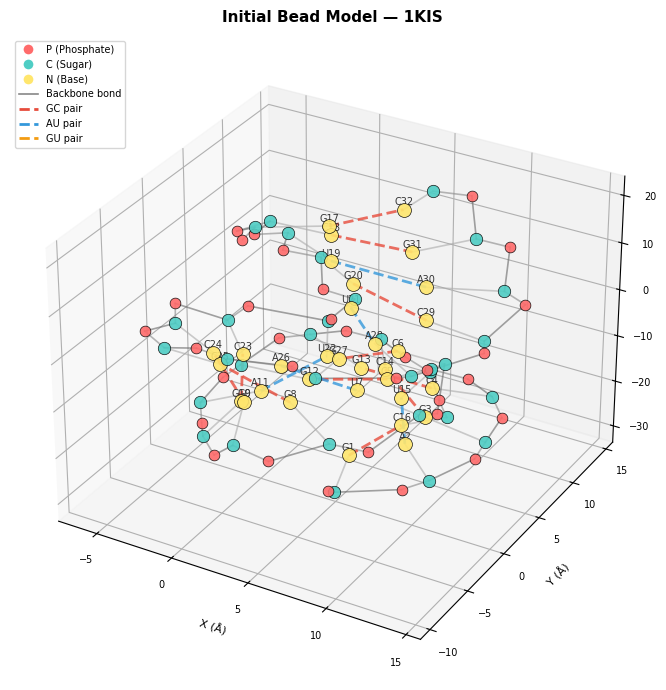

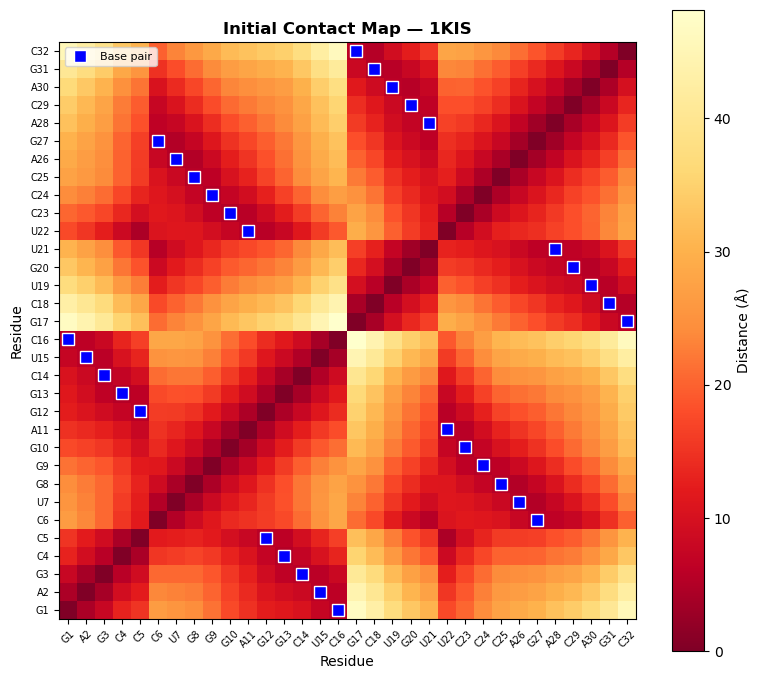


Calculating initial structure properties...
✓ Initial RMSD: 0.0000 Å

                         INITIAL STRUCTURE ENERGY ANALYSIS (1kis)                         

Energy Term                                  Value (kcal/mol)           % of Total
------------------------------------------------------------------------------------------
U_a (Angle)                                      131.24658298                7.37%
U_b (Bond)                                      1067.36608234               59.97%
U_bp (Base Pairing)                               -0.47627945               -0.03%
U_bs (Base Stacking)                              -0.06170485               -0.00%
U_cs (Coaxial Stacking)                           -8.35398065               -0.47%
U_d (Dihedral)                                     7.34468220                0.41%
U_el (Electrostatic)                             582.88122314               32.75%
U_exc (Excluded Volume)                            0.00000000                0.00%

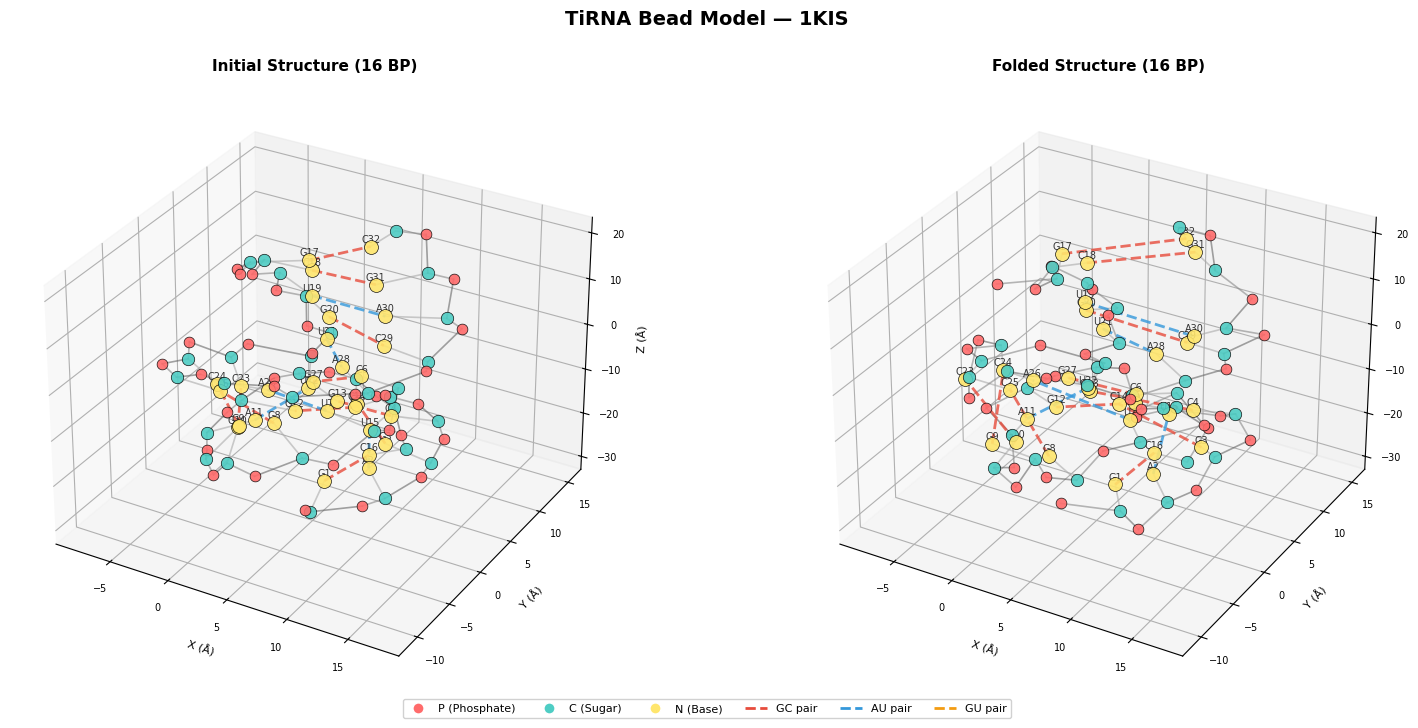

✓ Figure saved to: 1kis_model4_tiRNA_convergence.png


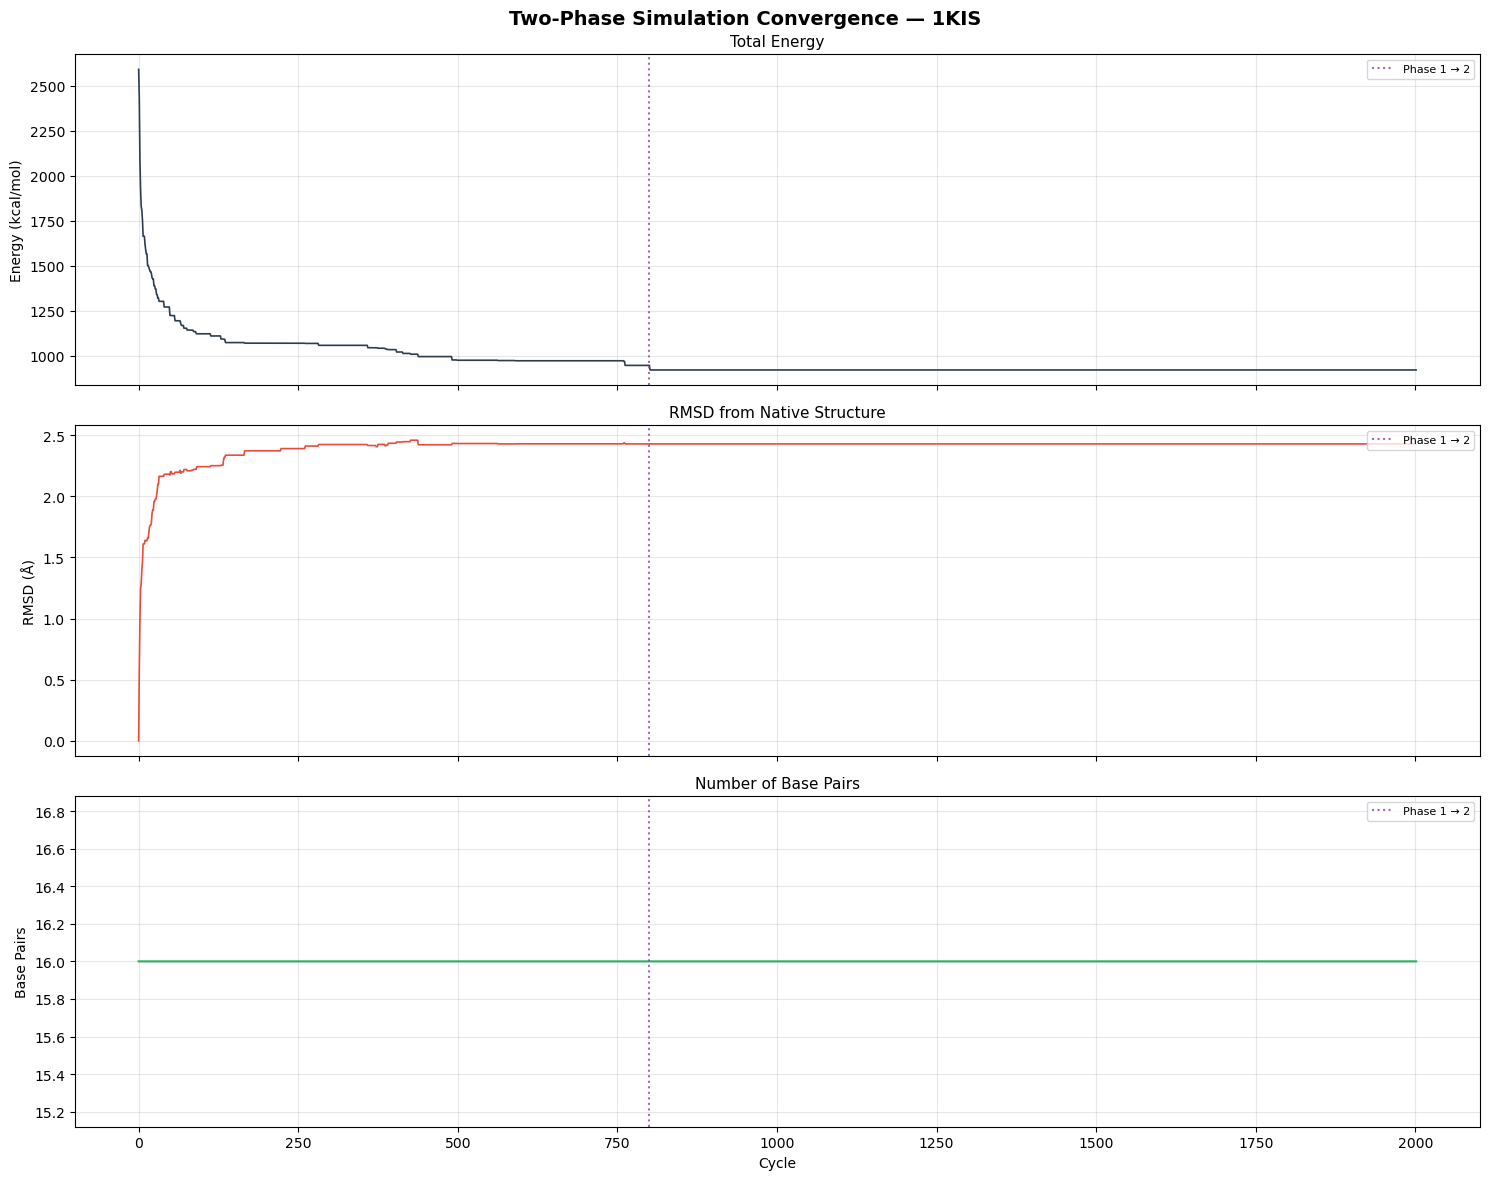

✓ Figure saved to: 1kis_model4_tiRNA_ini_contact_map.png


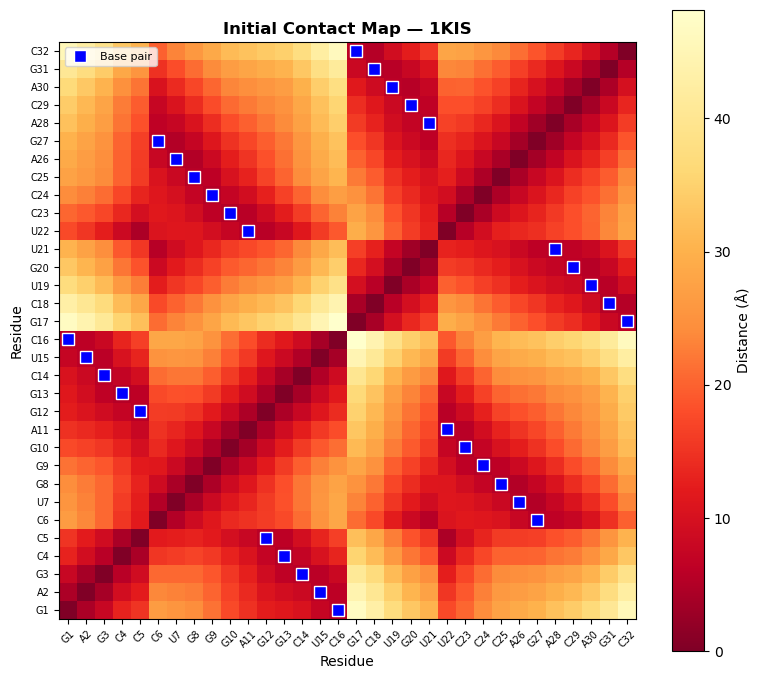

✓ Figure saved to: 1kis_model4_tiRNA_final_contact_map.png


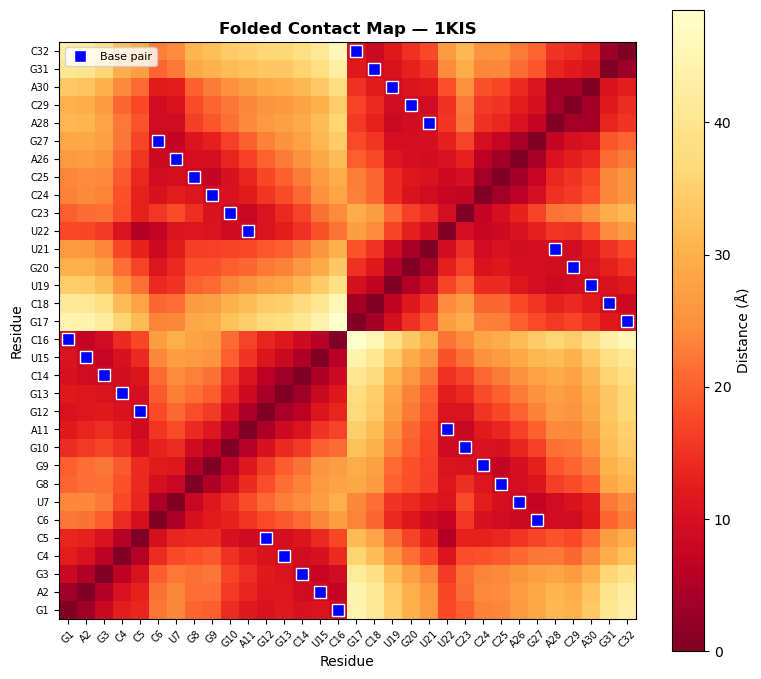

✓ Figure saved to: 1kis_model4_tiRNA_rmsd.png


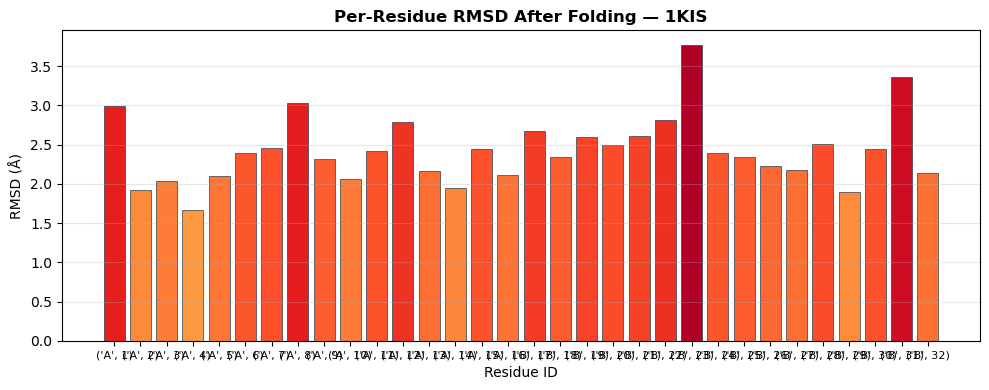

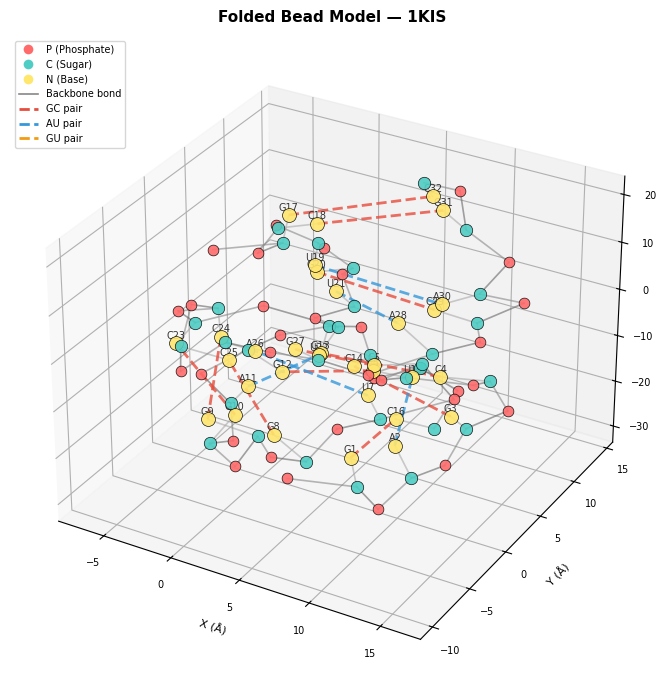


Generating interactive 3D visualization...

Initial configuration...
✓ Interactive plot saved to: 1kis_initial_tiRNA_interactive_3d.html


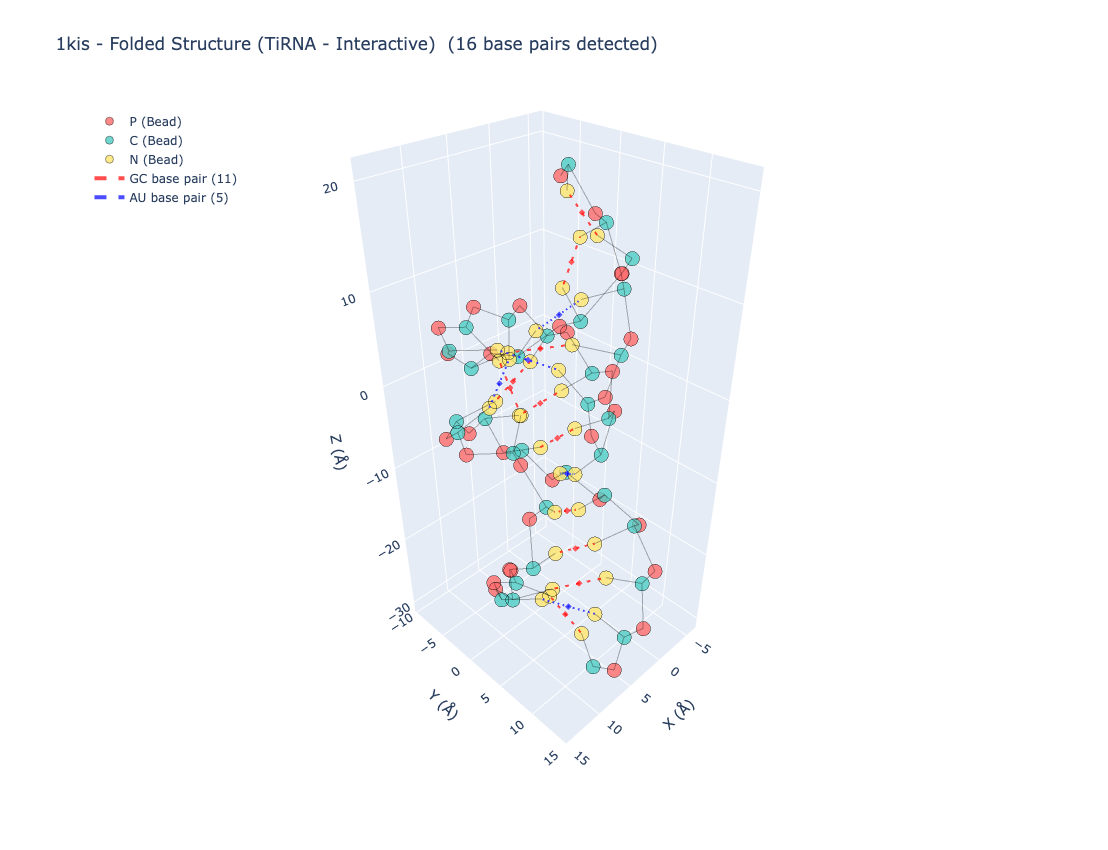


Final configuration...
✓ Interactive plot saved to: 1kis_final_tiRNA_interactive_3d.html


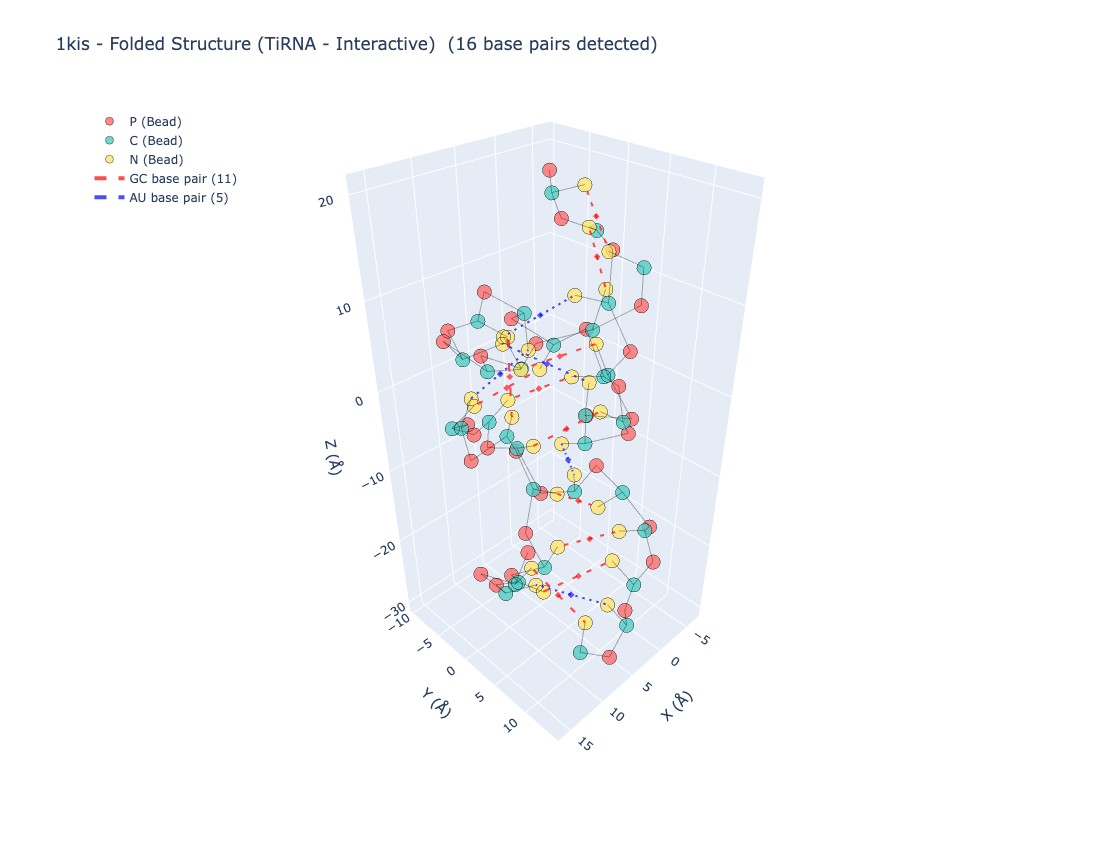


✓ Cleaned up PDB file

Analysis complete!



In [9]:
if __name__ == "__main__":
    main()

In [4]:
import os 
print(os.getcwd())

/Users/chee
